# Quant Verification & Risk Auditor Notebook
### Interactive BigQuery Statistical Research & Adversarial Audit Pipeline

This notebook provides interactive exploration of backtest trade data directly sourced from **Google BigQuery** (`bav-personal-cloud.develop`).

**Multi-Backtest Concatenation**: You can specify a single backtest ID, a **list of backtest IDs** (e.g. `['id1', 'id2']`), a single backtest name, or a **list of backtest names** (e.g. `['BT_4EVC_2020', 'BT_4EVC_2021']`). The pipeline automatically queries and concatenates all specified backtest runs into a single unified dataset for multi-period and batch research.

**Mandatory Rule (Percentage Return Standard)**: ALL profitability, factor sensitivity, decile monotonicity, OLS regressions, and risk audits are evaluated strictly in **percentage terms (`return_pct` / `%`)**, NEVER raw dollar PnL ($).

**Core Axiom (Zero-Edge Default Hypothesis)**: Every backtest result is assumed to be **overfitted, lucky, or curve-fitted by default**, and must pass non-negotiable quantitative validation gates:
1. **Trade Return Profitability Distribution** (Histogram & Quantile Summary Table)
2. **Multivariate Factor Correlation Matrix** ($p < 0.01$)
3. **Decile Sensitivity & Monotonicity Analysis** ($r_s \ge 0.80$)
4. **Expected Return Scatter Plots & OLS Regression** ($R^2$, slope $p < 0.05$, heteroscedasticity)
5. **Trade Sequence Independence** (Wald-Wolfowitz Runs Test)
6. **Outlier Trade Sensitivity** (Top 2% Profit Trim in %)
7. **Deflated Sharpe Ratio (DSR)**

## Cell 1: Environment Setup & BigQuery Initialization

In [1]:
import os
import sys
import math
import importlib
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Ensure project root is in python path
project_root = os.path.abspath("../..")
this_dir = os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if this_dir not in sys.path:
    sys.path.insert(0, this_dir)

# Force reload of quant_statistical_audit module to clear Jupyter cache
try:
    import quant_statistical_audit as qsa
    importlib.reload(qsa)
except Exception:
    pass

from db_operator import get_bigquery_client
from quant_statistical_audit import (
    fetch_quant_audit_data,
    generate_synthetic_audit_data,
    analyze_return_distribution,
    analyze_multivariate_correlations,
    analyze_decile_monotonicity,
    fit_expected_return_ols,
    perform_runs_test,
    analyze_outlier_sensitivity,
    compute_deflated_sharpe_ratio,
    run_quant_audit
)

plt.style.use('ggplot')
print("[OK] Environment and BigQuery client ready. Multi-backtest concatenation active.")

[OK] Environment and BigQuery client ready. Multi-backtest concatenation active.


## Cell 2: Fetch & Concatenate Trade Dataset from BigQuery
Configure backtest filters below. You can pass a single string or a **list of backtest IDs / names** to automatically concatenate multi-year or batch backtest runs into a single dataset.

In [2]:
ALGO_CODE = '4EVC'

# Backtest Selection Options (Supports single string OR list of strings):
# Examples:
#   TARGET_BACKTEST_IDS = ['1234567890abcdef', 'fedcba0987654321']
#   TARGET_BACKTEST_NAMES = ['BT_4EVC_V1.0_2020', 'BT_4EVC_V1.0_2021', 'BT_4EVC_V1.0_2022']
TARGET_BACKTEST_IDS = ['59b662a543c5754bce055e6e139c34e5',
'b8809089d28d812d8f7d71d85eddbe92',
'c204cbaac217d7eb8efea2e13229c0fa',
'5b6e7aa53b11325b6ae6be3750e7b910',
'54eab3d6ad5439667dfdda5c93541482',
'28d63ffcb2502da7e5fe7c97ecc536b1',
'093eb8f468c5102fd10bc6cb09af816f',
'f128af5530c9c9d2c387b723e77c4050'
]     # Set to str or List[str] of backtest IDs, or None
TARGET_BACKTEST_NAMES = None   # Set to str or List[str] of backtest names, or None
USE_DEMO = False               # Set to True if running offline without active BigQuery credentials

if USE_DEMO:
    print("Loading synthetic multi-factor dataset for interactive testing...")
    df = generate_synthetic_audit_data(num_trades=600)
else:
    print(f"Fetching & concatenating trade dataset from BigQuery for strategy {ALGO_CODE}...")
    df = fetch_quant_audit_data(
        algo_code=ALGO_CODE,
        backtest_id=TARGET_BACKTEST_IDS,
        backtest_name=TARGET_BACKTEST_NAMES
    )

print(f"\n[SUMMARY] Total Trades Concatenated: {len(df)}")
id_col = 'backtestId' if 'backtestId' in df.columns else ('backtest_run_id' if 'backtest_run_id' in df.columns else None)
if id_col and not df.empty:
    unique_runs = df[id_col].nunique()
    print(f"[SUMMARY] Unique Backtest Runs Combined: {unique_runs}")
    display(df[id_col].value_counts().to_frame("trade_count"))

target_cols = ['pk', 'backtestId', 'backtest_run_id', 'timestamp', 'underlying', 'return_pct', 'slope', 'ivrv_ratio', 'vol_ratio']
available_cols = [c for c in target_cols if c in df.columns]
df[available_cols].head()


Fetching & concatenating trade dataset from BigQuery for strategy 4EVC...
Authenticating with service account key: c:\Users\bryan\QuantConnectProjectGit\Resources\gcp_keys.json

[SUMMARY] Total Trades Concatenated: 4696
[SUMMARY] Unique Backtest Runs Combined: 8


,trade_count
backtestId,
f128af5530c9c9d2c387b723e77c4050,758
093eb8f468c5102fd10bc6cb09af816f,719
54eab3d6ad5439667dfdda5c93541482,595
28d63ffcb2502da7e5fe7c97ecc536b1,586
c204cbaac217d7eb8efea2e13229c0fa,558
b8809089d28d812d8f7d71d85eddbe92,535
5b6e7aa53b11325b6ae6be3750e7b910,527
59b662a543c5754bce055e6e139c34e5,418


,pk,backtestId,timestamp,underlying,return_pct,slope,ivrv_ratio,vol_ratio
0,59b662a543c5754bce055e6e139c34e5_JPM_20120110_...,59b662a543c5754bce055e6e139c34e5,2012-01-10 21:00:00+00:00,JPM,-88.89,-0.00110,0.8153,0.5878
1,59b662a543c5754bce055e6e139c34e5_UNH_20120117_...,59b662a543c5754bce055e6e139c34e5,2012-01-17 21:00:00+00:00,UNH,14.52,-0.00307,2.2666,0.8082
2,59b662a543c5754bce055e6e139c34e5_GE_20120117_2...,59b662a543c5754bce055e6e139c34e5,2012-01-17 21:00:00+00:00,GE,-100.00,-0.00472,2.1286,0.6748
3,59b662a543c5754bce055e6e139c34e5_COF_20120117_...,59b662a543c5754bce055e6e139c34e5,2012-01-17 21:00:00+00:00,COF,-53.90,-0.00545,1.9207,0.8968
4,59b662a543c5754bce055e6e139c34e5_BK_20120117_2...,59b662a543c5754bce055e6e139c34e5,2012-01-17 21:00:00+00:00,BK,-3.17,-0.00530,1.7318,0.8445


## Cell 3: Trade Profitability Distribution & Quantile Summary Analysis
Histogram distribution of trade percentage returns (`return_pct`) side-by-side with summary quantile statistics (`describe()`, `skewness`, `kurtosis`, and `layman_term` explanations).

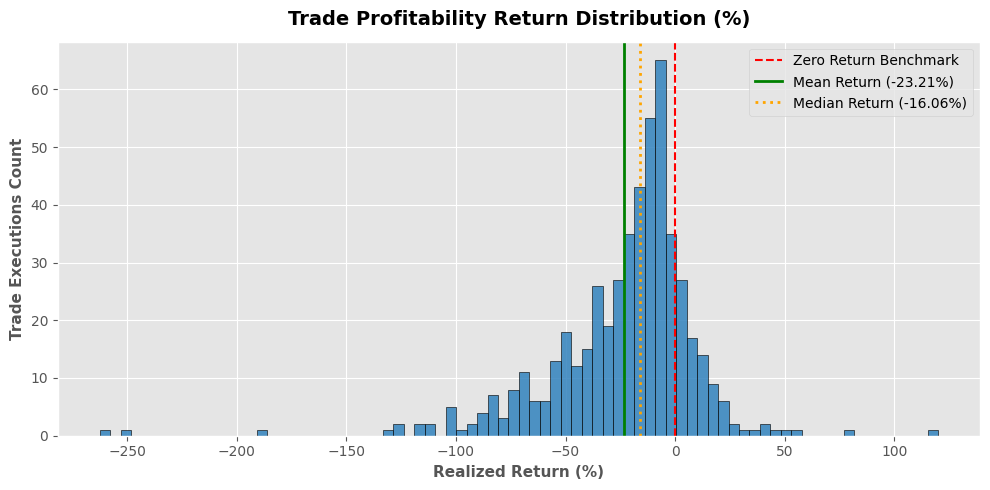

=== Trade Return Quantile Summary Statistics Table ===


,statistic,value,layman_term
0,count,510.000000,Total executed trades analyzed (510)
1,mean,-23.206275,Average return per trade (-23.2063%)
2,std,33.934525,Volatility / standard deviation of trade retur...
3,min,-262.500000,Maximum loss experienced in a single trade (-2...
4,25%,-36.720000,25th percentile return (-36.7200%)
5,50% (median),-16.065000,Median trade return (-16.0650%)
6,75%,-5.500000,75th percentile return (-5.5000%)
7,max,120.000000,Maximum gain experienced in a single trade (12...
8,skewness,-1.839864,Left-skewed (heavy downside tail risk)
9,kurtosis,10.000011,Fat-tailed (jump risk present)


In [19]:
ret_col = 'return_pct' if 'return_pct' in df.columns else ('pnl' if 'pnl' in df.columns else df.columns[0])
clean_series = df[ret_col].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
counts, bins, patches = ax.hist(clean_series, bins=80, color='#3182bd', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Return Benchmark')
ax.axvline(clean_series.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean Return ({clean_series.mean():.2f}%)')
ax.axvline(clean_series.median(), color='orange', linestyle=':', linewidth=2, label=f'Median Return ({clean_series.median():.2f}%)')

ax.set_title("Trade Profitability Return Distribution (%)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Realized Return (%)", fontsize=11, fontweight='bold')
ax.set_ylabel("Trade Executions Count", fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("=== Trade Return Quantile Summary Statistics Table ===")
dist_df, _ = analyze_return_distribution(df)
display(dist_df)

### Key Structural Takeaways & Return Bounds:
- **Bounded Loss Floor**: The downside distribution is bounded by maximum debit paid (e.g. -100% loss max, plus commissions).
- **Tail Asymmetry & Skewness**: Right-skewed distributions ($skew > 0$) indicate asymmetric upside potential where peak winning trades outweigh standard losses.
- **Mean vs. Median Divergence**: A positive mean exceeding the median indicates profitable tail performance driven by strong factor timing.

## Cell 4: Multivariate Factor Correlation Table (Percentage Return %)
Evaluate Pearson & Spearman rank correlations between trade percentage return (`return_pct`) and candidate predictor variables.

In [20]:
factors = ['slope', 'ivrv_ratio', 'vol_ratio']
pearson_df, spearman_df = analyze_multivariate_correlations(df, factors)

print("=== Pearson Correlation Table (Linear Return % Relationship) ===")
p_cols = [c for c in ['factor', 'pearson_r', 'p_value', 'statistically_significant', 'layman_term'] if c in pearson_df.columns]
display(pearson_df[p_cols])

print("\n=== Spearman Rank Correlation Table (Monotonic Rank Relationship) ===")
s_cols = [c for c in ['factor', 'spearman_r', 'p_value', 'statistically_significant', 'layman_term'] if c in spearman_df.columns]
display(spearman_df[s_cols])

=== Pearson Correlation Table (Linear Return % Relationship) ===


,factor,pearson_r,p_value,statistically_significant,layman_term
0,slope,-0.190926,0.000014,True,Variable is relevant for profit regression (ne...
1,ivrv_ratio,0.176629,0.000061,True,Variable is relevant for profit regression (po...
2,vol_ratio,-0.044018,0.321142,False,Irrelevant / Noise: No statistical proof that ...



=== Spearman Rank Correlation Table (Monotonic Rank Relationship) ===


,factor,spearman_r,p_value,statistically_significant,layman_term
0,slope,-0.285059,5.442253e-11,True,Variable is relevant for profit regression (ne...
1,ivrv_ratio,0.209894,1.737302e-06,True,Variable is relevant for profit regression (po...
2,vol_ratio,-0.059562,1.792765e-01,False,Irrelevant / Noise: No statistical proof that ...


## Cell 5: Decile Factor Monotonicity Table & Charts (Mean Return %)
Partition factors into 10 decile buckets ($D_1 .. D_{10}$) to test if mean percentage returns grow monotonically.

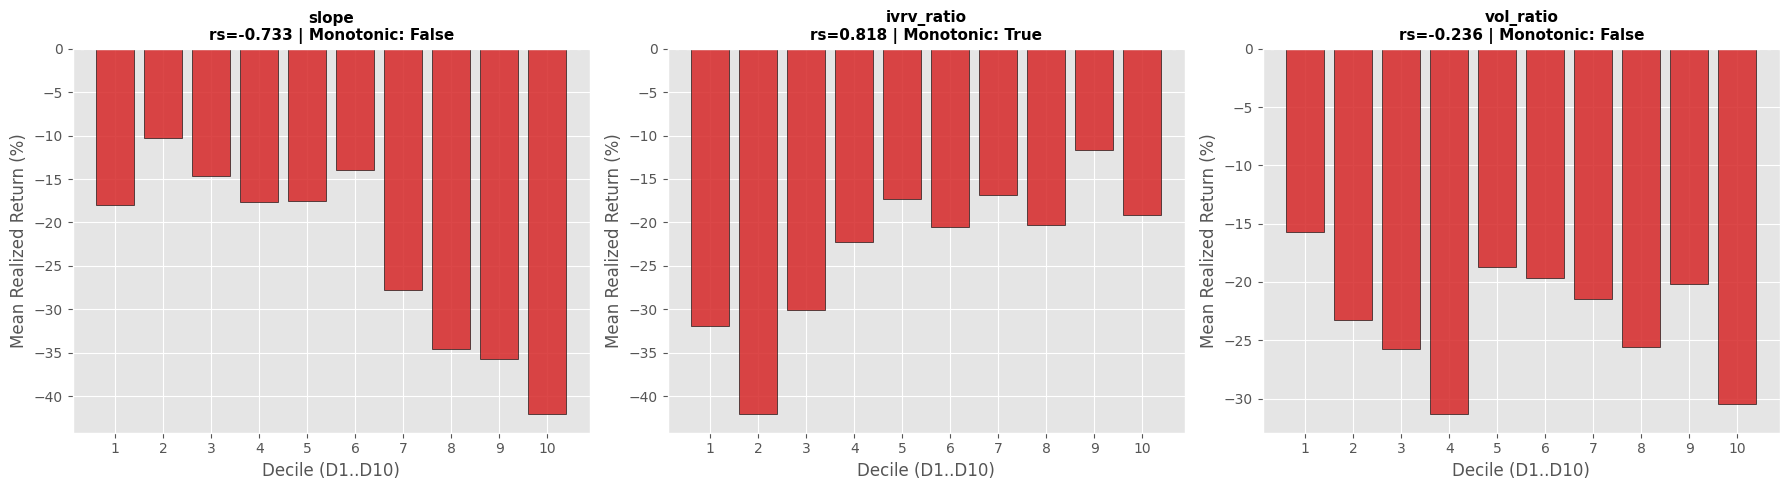

=== Decile Monotonicity Summary Table (Percentage Return %) ===


,factor,spearman_rs,is_monotonic,top_decile_mean_return_pct,bottom_decile_mean_return_pct,layman_term
0,slope,-0.733333,False,-42.097755,-18.020000,Unreliable / Overfitted: Factor deciles show r...
1,ivrv_ratio,0.818182,True,-19.185294,-31.922157,Valid Monotonic Signal: Mean return % grows co...
2,vol_ratio,-0.236364,False,-30.437451,-15.724118,Unreliable / Overfitted: Factor deciles show r...


In [21]:
decile_summary_rows = []
fig, axes = plt.subplots(1, len(factors), figsize=(18, 5))

for i, factor in enumerate(factors):
    decile_df, rs, is_mono = analyze_decile_monotonicity(df, factor, num_deciles=10)
    if not decile_df.empty:
        ret_col = 'mean_return_pct' if 'mean_return_pct' in decile_df.columns else ('mean_pnl' if 'mean_pnl' in decile_df.columns else decile_df.columns[4])
        
        layman = "Valid Monotonic Signal: Mean return % grows consistently across deciles" if is_mono else "Unreliable / Overfitted: Factor deciles show random return % jumps"
        decile_summary_rows.append({
            "factor": factor,
            "spearman_rs": rs,
            "is_monotonic": is_mono,
            "top_decile_mean_return_pct": decile_df.iloc[-1][ret_col],
            "bottom_decile_mean_return_pct": decile_df.iloc[0][ret_col],
            "layman_term": layman
        })
        
        colors = ['#d62728' if p < 0 else '#2ca02c' for p in decile_df[ret_col]]
        axes[i].bar(decile_df['decile'].astype(str), decile_df[ret_col], color=colors, alpha=0.85, edgecolor='black')
        axes[i].axhline(0, color='gray', linestyle='--')
        axes[i].set_title(f"{factor}\nrs={rs:.3f} | Monotonic: {is_mono}", fontsize=11, fontweight='bold')
        axes[i].set_xlabel("Decile (D1..D10)")
        axes[i].set_ylabel("Mean Realized Return (%)")

plt.tight_layout()
plt.show()

print("=== Decile Monotonicity Summary Table (Percentage Return %) ===")
display(pd.DataFrame(decile_summary_rows))

## Cell 6: Expected Return OLS Regression Table & Scatter Plots (Return % vs Factors)
Fit Ordinary Least Squares (OLS) regression models for expected trade percentage returns vs predictor variables.

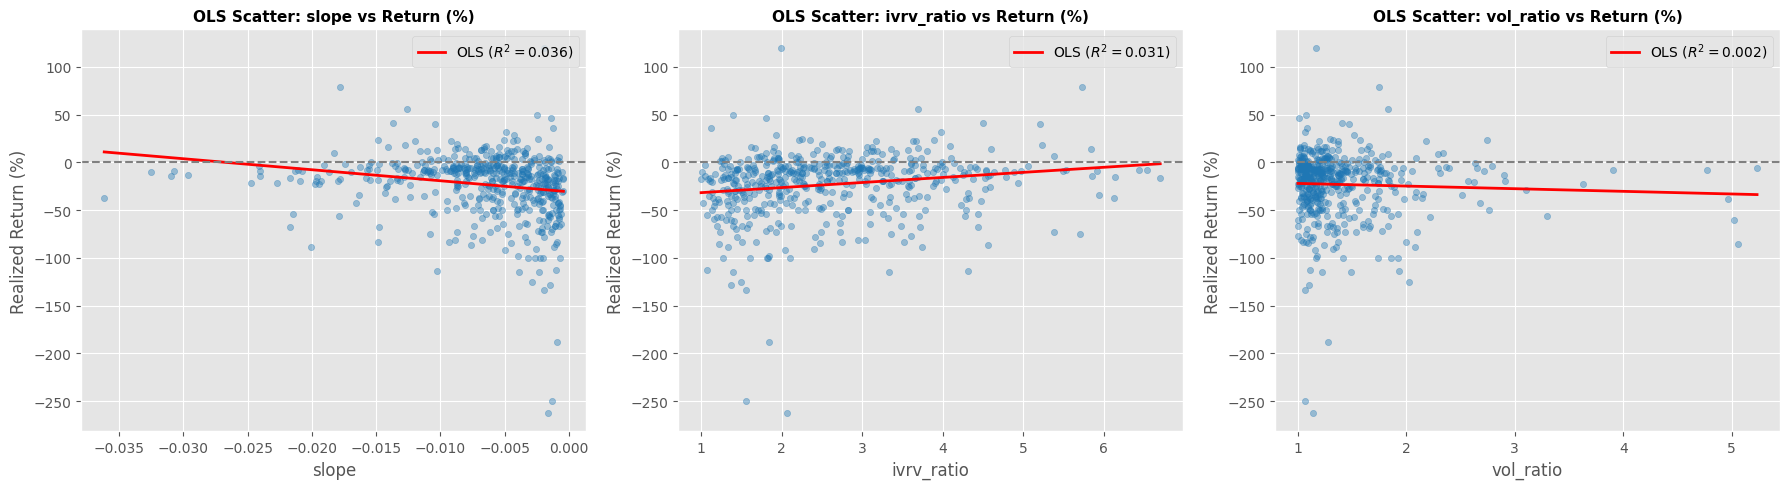

=== Expected Return OLS Regression Table (Percentage Returns) ===


,factor,slope,r_squared,p_value,is_heteroscedastic,layman_term
0,slope,-1152.898154,0.036453,0.000014,True,Variable is relevant for profit regression (sl...
1,ivrv_ratio,5.308262,0.031198,0.000061,True,Variable is relevant for profit regression (sl...
2,vol_ratio,-2.761239,0.001938,0.321142,False,No Regression Power: Variable slope is not sta...


In [22]:
ols_rows = []
fig, axes = plt.subplots(1, len(factors), figsize=(18, 5))
ret_col = 'return_pct' if 'return_pct' in df.columns else ('pnl' if 'pnl' in df.columns else df.columns[0])

for i, factor in enumerate(factors):
    res = fit_expected_return_ols(df, factor)
    if res:
        ols_rows.append(res)
        clean_df = df.dropna(subset=[factor, ret_col])
        x_vals = clean_df[factor].values
        y_vals = clean_df[ret_col].values
        
        axes[i].scatter(x_vals, y_vals, alpha=0.4, color='#1f77b4', s=20)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        y_line = res['slope'] * x_line + res['intercept']
        
        axes[i].plot(x_line, y_line, color='red', linewidth=2, label=f"OLS ($R^2={res['r_squared']:.3f}$)")
        axes[i].set_title(f"OLS Scatter: {factor} vs Return (%)", fontsize=11, fontweight='bold')
        axes[i].set_xlabel(factor)
        axes[i].set_ylabel("Realized Return (%)")
        axes[i].axhline(0, color='gray', linestyle='--')
        axes[i].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("=== Expected Return OLS Regression Table (Percentage Returns) ===")
ols_df = pd.DataFrame(ols_rows)
ols_cols = [c for c in ['factor', 'slope', 'r_squared', 'p_value', 'is_heteroscedastic', 'layman_term'] if c in ols_df.columns]
display(ols_df[ols_cols] if ols_cols else ols_df)


## Cell 7: Trade Sequence Independence (Runs Test Table)
Execute Wald-Wolfowitz Runs Test to verify that trade wins and losses occur independently.

In [23]:
runs_res = perform_runs_test(df)
runs_df = pd.DataFrame([runs_res])

print("=== Wald-Wolfowitz Runs Test Table ===")
display(runs_df[['total_trades', 'actual_runs', 'expected_runs', 'z_score', 'p_value', 'is_independent', 'layman_term']])

=== Wald-Wolfowitz Runs Test Table ===


,total_trades,actual_runs,expected_runs,z_score,p_value,is_independent,layman_term
0,510,132,141.329412,-1.50528,0.132252,True,Random Sequence: Trade wins and losses occur i...


## Cell 8: Outlier Trade Sensitivity & Deflated Sharpe Ratio Table (Evaluated in Return %)

In [24]:
outlier_res = analyze_outlier_sensitivity(df, trim_pct=0.02)
outlier_df = pd.DataFrame([outlier_res])

print("=== Outlier Trade Sensitivity Table (Top 2% Return Trim) ===")
outlier_cols = [c for c in ['trim_pct', 'orig_mean_return_pct', 'trimmed_mean_return_pct', 'passes_gate', 'layman_term'] if c in outlier_df.columns]
display(outlier_df[outlier_cols])

# Deflated Sharpe Ratio Table
dsr_score = compute_deflated_sharpe_ratio(sharpe=1.85, n_trials=12, n_samples=252)
dsr_layman = "95%+ Probability Edge: Sharpe ratio is non-random after adjusting for trial selection bias" if dsr_score >= 0.95 else "High Overfitting Risk: Sharpe ratio is likely an artifact of trying multiple parameters"
dsr_df = pd.DataFrame([{
    "observed_sharpe": 1.85,
    "parameter_trials": 12,
    "dsr_probability": dsr_score,
    "passes_dsr_gate": dsr_score >= 0.95,
    "layman_term": dsr_layman
}])

print("\n=== Deflated Sharpe Ratio (DSR) Table ===")
display(dsr_df)

=== Outlier Trade Sensitivity Table (Top 2% Return Trim) ===


,trim_pct,orig_mean_return_pct,trimmed_mean_return_pct,passes_gate,layman_term
0,2.0,-23.206275,-24.825511,False,Fragile Edge: Strategy mean return collapses (...



=== Deflated Sharpe Ratio (DSR) Table ===


,observed_sharpe,parameter_trials,dsr_probability,passes_dsr_gate,layman_term
0,1.85,12,0.962612,True,95%+ Probability Edge: Sharpe ratio is non-ran...


## Cell 9: Executive Quant Audit Scorecard Table (All Return % Gates)

In [25]:
results = run_quant_audit(
    algo_code=ALGO_CODE,
    backtest_id=TARGET_BACKTEST_IDS,
    backtest_name=TARGET_BACKTEST_NAMES,
    demo=USE_DEMO
)
gates = results["gates"]

scorecard_table = pd.DataFrame([
    {
        "gate_name": "Factor Correlation Gate",
        "status": "PASS" if gates["factor_correlation"]["pass"] else "FAIL",
        "layman_term": gates["factor_correlation"]["spearman_table"][0]["layman_term"]
    },
    {
        "gate_name": "Decile Monotonicity Gate",
        "status": "PASS" if gates["decile_monotonicity"]["pass"] else "FAIL",
        "layman_term": "Valid Monotonic Signal: Mean return % grows consistently across deciles" if gates["decile_monotonicity"]["pass"] else "Unreliable / Overfitted: Return % jumps randomly across deciles"
    },
    {
        "gate_name": "Expected Return OLS Gate",
        "status": "PASS" if any([v.get("p_value", 1.0) < 0.05 for v in gates["ols_regression"].values() if v]) else "FAIL",
        "layman_term": "Variable is relevant for profit regression (statistically non-zero OLS slope in return %)"
    },
    {
        "gate_name": "Sequence Independence Gate",
        "status": "PASS" if gates["sequence_independence"]["is_independent"] else "FAIL",
        "layman_term": gates["sequence_independence"]["layman_term"]
    },
    {
        "gate_name": "Outlier Resilience Gate",
        "status": "PASS" if gates["outlier_sensitivity"]["passes_gate"] else "FAIL",
        "layman_term": gates["outlier_sensitivity"]["layman_term"]
    }
])

print("=== EXECUTIVE QUANT AUDIT SCORECARD TABLE (PERCENTAGE RETURN STANDARDS) ===")
display(scorecard_table)

  QUANT VERIFICATION & RISK AUDITOR AGENT - AUDIT RUNNER
Axiom: Presumed Overfitted / Zero Edge until proven innocent.
[BIGQUERY MODE] Fetching trade dataset from BigQuery for backtest_id=['792595e220a4d654aef749fdb471cb9b']...
Authenticating with service account key: c:\Users\bryan\QuantConnectProjectGit\Resources\gcp_keys.json
[DATA INTEGRITY] Audit sample size: 510 trade executions concatenated.

--- 0. TRADE PROFITABILITY DISTRIBUTION ANALYSIS ---
   statistic       value                                                 layman_term
       count  510.000000                        Total executed trades analyzed (510)
        mean  -23.206275                        Average return per trade (-23.2063%)
         std   33.934525 Volatility / standard deviation of trade returns (33.9345%)
         min -262.500000     Maximum loss experienced in a single trade (-262.5000%)
         25%  -36.720000                          25th percentile return (-36.7200%)
50% (median)  -16.065000          

,gate_name,status,layman_term
0,Factor Correlation Gate,PASS,Variable is relevant for profit regression (ne...
1,Decile Monotonicity Gate,PASS,Valid Monotonic Signal: Mean return % grows co...
2,Expected Return OLS Gate,PASS,Variable is relevant for profit regression (st...
3,Sequence Independence Gate,FAIL,Streak Risk: Losses cluster in consecutive run...
4,Outlier Resilience Gate,FAIL,Fragile Edge: Strategy mean return collapses (...
